In [1]:
%matplotlib widget
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import os
print(os.getpid())
%cd ../../

import pylib.mix as mix
import cvxpy as cp
import pylib.qucf_read as qucf_r
import pylib.measurement as mse

from matplotlib import colors
colors_ = ["blue", "red", "green", "gray", "black"]

plt.rcParams.update({
    "text.usetex": True,
    'text.latex.preamble': r"\usepackage{amsmath} \boldmath"
})

27193
/media/work/docs/codes/QuCF/scripts-py


In [2]:
path_save_ = "./jupyter-notebooks/Stepanoff/results/"
path_qucf_ = "../QuCF/simulations/Stepanoff/BE"
for i in range(100):
    plt.close()

In [33]:
# ---------------------------------------------------
# --- Helper functions ---
# ---------------------------------------------------
def plot_matrix(
        A, Nx, 
        name_A = "", label_A = "", 
        step_tick = 10,
        fontsize = 30, marker_size = 80,
        text_coord_label = [1, 14],
        text_coord_name_A = [12, 1],
):
    def find_rows_columns(A):
        N = A.shape[0]
        rows_plot_1 = np.zeros(N*N)
        cols_plot_1 = np.zeros(N*N)
        N_nz_1 = 0
        for ir in range(N):
            for ic in range(N):
                if np.abs(A[ir, ic]) > 0:
                    N_nz_1 += 1
                    rows_plot_1[N_nz_1-1] = ir
                    cols_plot_1[N_nz_1-1] = ic
        rows_plot_1 = rows_plot_1[0:N_nz_1]
        cols_plot_1 = cols_plot_1[0:N_nz_1]
        return rows_plot_1, cols_plot_1
    # -----------------------------------------------
    marker_size = int(marker_size / (Nx/4.)**2)

    N = A.shape[0]
    rows_A, cols_A = find_rows_columns(A)

    fig1 = plt.figure(figsize=(11,10))
    ax = fig1.add_subplot(111)
    ax.scatter(cols_A, rows_A, color="red", s = marker_size) 
    plt.xlim(0, N - 1)
    plt.ylim(0, N - 1)
    plt.gca().invert_yaxis()
    plt.xlabel(r'$\textbf{columns}$', fontsize = fontsize)
    plt.ylabel(r"$\textbf{rows}$", fontsize = fontsize)
    plt.grid()

    plt.yticks(np.arange(0, N, step_tick))
    plt.xticks(np.arange(0, N, step_tick))

    ax.tick_params(axis='both', which='major', labelsize=fontsize)

    if Nx > 4:
        # ax.set_xticks([])
        ax.tick_params(axis='both', which='major', labelbottom=False, labelleft=False)


    # ax.text(
    #     int(text_coord_label[0]), int(text_coord_label[1]), 
    #     r'$\textbf{' + label_A + '}$', fontsize=fontsize
    # )
    
    # ax.text(
    #     int(text_coord_name_A[0]), int(text_coord_name_A[1]), 
    #     r'$' + name_A + '$', fontsize=fontsize
    # )

    # --- Indicate blocks ---
    for ii in range(Nx):
        ax.hlines(y=ii * Nx - 0.5, xmin=0, xmax=N, linewidth=2, color='black')
        ax.vlines(x=ii * Nx - 0.5, ymin=0, ymax=N, linewidth=2, color='black')

    # --- plot diagonal ---
    for ii in range(0, Nx):
        ax.plot([ii*Nx,N], [0, N-ii*Nx], "--b")
    for ii in range(1, Nx):
        ax.plot([0,N-ii*Nx], [ii*Nx, N], "--b")

    plt.show()
    return

In [57]:
# -------------------------------------------------------
# --- Construct V matrix ---
# -------------------------------------------------------
def construct_matrices(nx, alpha, flag_opt1):
    Nx = 1 << nx
    Nx2 = Nx * Nx

    V  = np.zeros((Nx2, Nx2), dtype = complex)
    Dv = np.zeros((Nx2, Nx2))
    Sv = np.zeros((Nx2, Nx2))
    Av = np.zeros((Nx2, Nx2))

    # --- Choosing coordinate convention ---
    fcoord = None
    if flag_opt1:
        # option 1 
        fcoord = lambda r1, r2: r2 * Nx + r1
    else:
        # option 2
        fcoord = lambda r1, r2: r1 * Nx + r2

    # --- matrix elements ---
    fd = lambda c1, c2: (c1 + c2)
    fs = lambda c1, c2: - alpha_/2. * (c1 + c2)
    fa = lambda c1:     - (1. - alpha_)/2. * c1

    # --- Constructing matrices ---
    for r1 in range(Nx):
        for r2 in range(Nx):
            r = fcoord(r1,r2)

            # --- matrix D ---
            Dv[r,r] = fd(r1, r2)

            # --- matrix S ---
            if r2 > 0 and r1 < (Nx-1):
                c1, c2 = r1+1, r2-1
                cL = fcoord(c1, c2)
                Sv[r,cL] = fs(c1, c2)

            if r2 < (Nx-1) and r1 > 0:
                c1, c2 = r1-1, r2+1
                cR = fcoord(c1, c2)
                Sv[r, cR] = fs(c1, c2)

            # --- matrix A ---
            if r2 > 0:
                c1, c2 = r1, r2 - 1
                cL = fcoord(c1, c2)
                Av[r, cL] = fa(c1)

            if r2 < (Nx-1):
                c1, c2 = r1, r2 + 1
                cR = fcoord(c1, c2)
                Av[r, cR] = fa(c1)

    # --- the final matrix ---
    V = 1j * (Dv + Sv + Av)
    return V, Dv, Sv, Av, Nx, Nx2
# -------------------------------------------------------
flag_opt1_ = True
nx_ = 2
alpha_ = 0.6

V_, Dv_, Sv_, Av_, Nx_, Nx2_ = construct_matrices(nx_, alpha_, flag_opt1_)

mix.is_Hermitian(V_/1.j, "V")

the matrix V is Hermitian


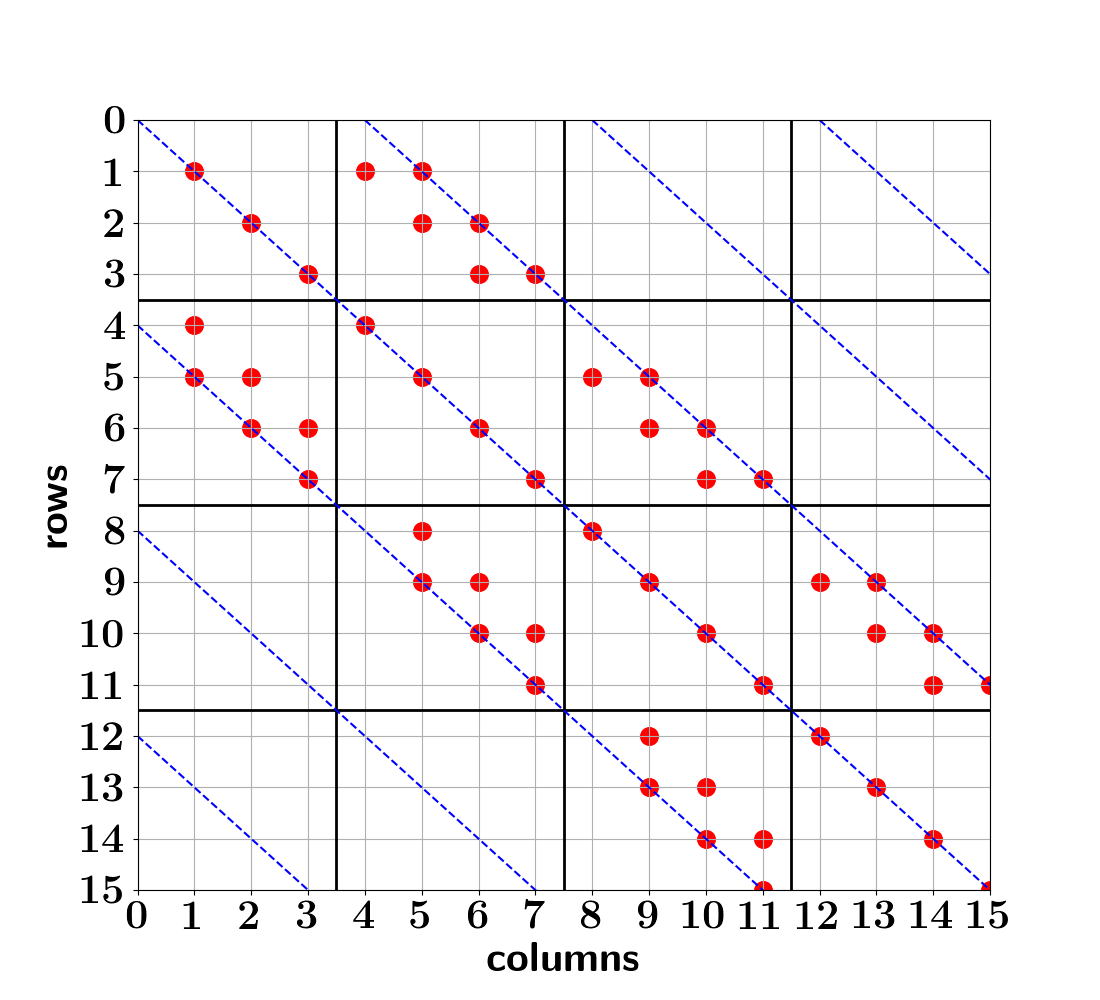

In [6]:
# -------------------------------------------------------
# --- Plot matrices ---
# -------------------------------------------------------
# plot_matrix(Dv_, Nx_, "D", "D", step_tick = 1)
# plot_matrix(Sv_, Nx_, "S", "S", step_tick = 1)
# plot_matrix(Av_, Nx_, "A", "A", step_tick = 1)
plot_matrix(V_, Nx_, "M", "M", step_tick = 1)

Reading the matrix from: be_OUTPUT.hdf5
from the path: ../QuCF/simulations/Stepanoff/BE
date of the simulation:  01-17-2025 13:21:36
matrix name:  U
N = 16

--- Elements in D in the diagonal -4 ---
 0.125  0.125  0.125  0.177 
 0.125  0.125  0.125  0.177 
 0.177  0.177  0.177  0.250 


--- Elements in D in the diagonal -3 ---
 0.000  0.125  0.125  0.125 
 0.000  0.125  0.125  0.125 
 0.000  0.177  0.177  0.177 
 0.000 


--- Elements in D in the diagonal 0 ---
 0.500  0.500  0.500  0.500 
 0.500  0.500  0.500  0.500 
 0.500  0.500  0.500  0.500 
 0.500  0.500  0.500  0.500 


--- Elements in D in the diagonal 3 ---
 0.000  0.177  0.177  0.177 
 0.000  0.125  0.125  0.125 
 0.000  0.125  0.125  0.125 
 0.000 


--- Elements in D in the diagonal 4 ---
 0.250  0.177  0.177  0.177 
 0.177  0.125  0.125  0.125 
 0.177  0.125  0.125  0.125 



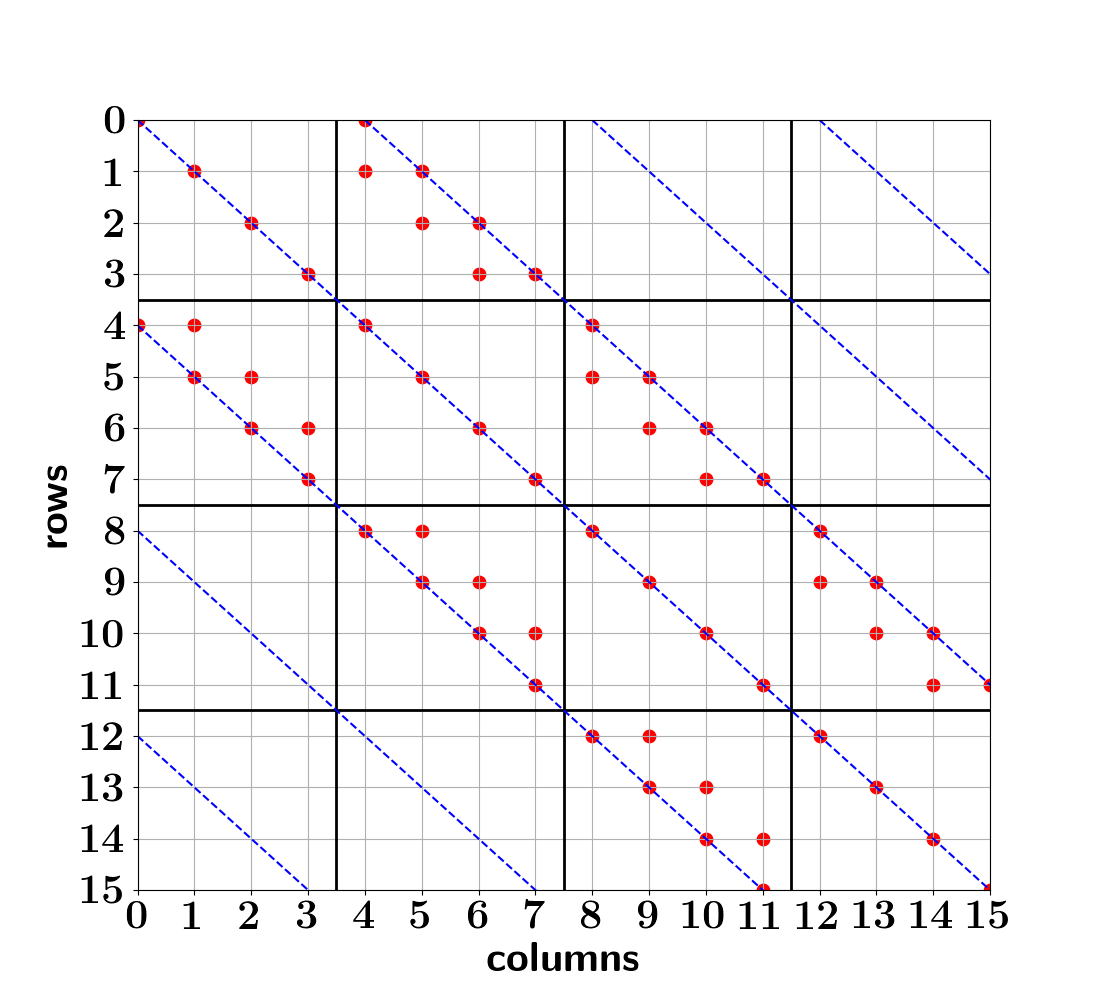

In [60]:
# --------------------------------------------------------------
# --- Reading D-matrix formed by OF and OM oracles ---
# --------------------------------------------------------------
def print_plot_D_elements(dd, id_diag, str_matrix):
    print("--- Elements in {:s} in the diagonal {:d} ---".format(str_matrix, id_diag))
    mix.print_array(
        mix.get_diag(dd["A"].form_dense_matrix(), id_diag)[0].real,
        n_in_row = Nx_,
        ff=[6, 3, "f"]
    )
    print()
# -----------------------------------------------------------------------------------
def printing_diagonals(dd):
    print()
    print_plot_D_elements(dd, -Nx_, "D")

    print()
    print_plot_D_elements(dd, -Nx_+1, "D")

    print()
    print_plot_D_elements(dd, 0, "D")

    print()
    print_plot_D_elements(dd, Nx_-1, "D")

    print()
    print_plot_D_elements(dd, Nx_, "D")
    return
# -----------------------------------------------------------------------------------
dd_loc = qucf_r.read_matrix_sparse(path_qucf_, "be_OUTPUT.hdf5")

printing_diagonals(dd_loc)

plot_matrix(dd_loc["A"].dense(), Nx_, "D", "D", step_tick = 1)

In [8]:
# -------------------------------------------------------------------------------
# --- Create a diagonal matrix with x-coordinates on the main diagonal ---
# -------------------------------------------------------------------------------
import qiskit
from qiskit.quantum_info import Operator, SparsePauliOp
print("qiskit version: ", qiskit.version.get_version_info())

# from qiskit import QuantumCircuit, QuantumRegister
# from qiskit.quantum_info.operators import Operator
# from qiskit.compiler import transpile
# from scipy.linalg import expm
# mix.reload_module(mix)

def create_diag_matrix(n, alpha):
    N = 1 << n
    aa = np.linspace(0, 2.*np.pi, N)
    c_arr = np.array(range(0,N))

    diag = np.zeros(N**2)
    count = -1
    for i2 in range(0,N):
        for i1 in range(0,N):
            count += 1
            diag[count] = alpha * i2 * (1. - np.cos(aa[i1]))

    A = np.diag(diag)
    op = Operator(A)
    A_dec = SparsePauliOp.from_operator(op)

    # A_dec = mix.hermitian_to_Z_pauli(A, flag_filter = True, small_coef = 1e-14, flag_print_details=True)
    # A_dec = mix.hermitian_to_pauli(A, flag_filter = True, small_coef = 1e-14, flag_print_details=True)
    return A, A_dec
# -----------------------------------------------------
t_ = 2
n_ = 3
N_ = 1 << n_
alpha_ = np.sqrt(20.)
A_diag, A_diag_dec = create_diag_matrix(n = n_, alpha = alpha_)

print("Number of Pauli products: {:d}", len(A_diag_dec))

qiskit version:  1.3.2
Number of Pauli products: {:d} 16


In [9]:
# -------------------------------------------------
# --- Show nonzero Pauli products ---
# -------------------------------------------------
for prod in A_diag_dec:
    print(prod.paulis,     prod.coeffs)

# for term_one in A_diag_dec:
#     print(term_one[0], "\t", term_one[2])

['IIIIII'] [13.696+0.j]
['IIIIZZ'] [1.182+0.j]
['IIIZIZ'] [-4.128+0.j]
['IIIZZI'] [-10.749+0.j]
['IIZIII'] [-1.957+0.j]
['IIZIZZ'] [-0.169+0.j]
['IIZZIZ'] [0.59+0.j]
['IIZZZI'] [1.536+0.j]
['IZIIII'] [-3.913+0.j]
['IZIIZZ'] [-0.338+0.j]
['IZIZIZ'] [1.179+0.j]
['IZIZZI'] [3.071+0.j]
['ZIIIII'] [-7.826+0.j]
['ZIIIZZ'] [-0.675+0.j]
['ZIIZIZ'] [2.359+0.j]
['ZIIZZI'] [6.142+0.j]


In [10]:
# -------------------------------------------------
# --- Plot the evolution circuit ---
# -------------------------------------------------
from qiskit.circuit.library import PauliEvolutionGate
from qiskit import QuantumCircuit

# Create evolution gate
evolution_gate = PauliEvolutionGate(A_diag_dec, time = 0.5)

# Add it to a quantum circuit
qc = QuantumCircuit(2*n_)
qc.append(evolution_gate, range(2*n_))

# Decompose into explicit gates
decomposed_qc = qc.decompose()
print(decomposed_qc)

global phase: 5.7184
                                                     ┌───┐┌──────────────┐┌───┐»
q_0: ──■─────────────■───────────────────────────────┤ X ├┤ Rz(-0.16879) ├┤ X ├»
       │ZZ(1.1815)   │                          ┌───┐└─┬─┘└──────────────┘└─┬─┘»
q_1: ──■─────────────┼─────────────■────────────┤ X ├──■────────────────────■──»
                     │ZZ(-4.1282)  │ZZ(-10.749) └─┬─┘                          »
q_2: ────────────────■─────────────■──────────────┼────────────────────────────»
     ┌─────────────┐                              │                            »
q_3: ┤ Rz(-1.9566) ├──────────────────────────────■────────────────────────────»
     ├─────────────┤                                                           »
q_4: ┤ Rz(-3.9131) ├───────────────────────────────────────────────────────────»
     ├─────────────┤                                                           »
q_5: ┤ Rz(-7.8262) ├───────────────────────────────────────────────────────────»
     └─

In [14]:
# -------------------------------------------------------
# --- Save the circuit for the exp(-1j * t_ * A_dec_) ---
# -------------------------------------------------------
fname = "M2_n{:d}.oracle".format(n_)
fullname = path_save_ + "/" + fname

name_qr = "r"  # name of the target register

print("Storing to: {:s}".format(fullname))
ff = open(fullname, "w")
counter_q = -1
for ii in range(len(A_diag_dec)):
    if list(A_diag_dec[ii][2]) == [0]*n_:
        continue
    counter_q += 1
    angle_Rz = A_diag_dec[ii][0] * 2. * t_
    str_az = "{:0.12e}".format(angle_Rz)
    line_one = "gate Rz {:s}[{:d}] {:s} end_gate".format(name_qr, counter_q, str_az)
    ff.write(line_one + "\n")
    print("az: {:0.12e}".format(angle_Rz))
ff.close()

Storing to: ./jupyter-notebooks/Stepanoff/results//M2_n2.oracle
az: 2.012461179750e+01
az: -2.012461179750e+01
az: -6.708203932499e+00
az: 6.708203932499e+00
az: -1.341640786500e+01
az: 1.341640786500e+01
